# Downloading and Prepping data for Projecting Yearly Bat Speed 

This file
- Aggregates year data over each player season
- Clean data for downstream modeling
- Visualizes exit velocity and bat speed yearly data

This file is very similar to the monthly bat speed file, just swapping month_name for year.

## Preparing the data

In [1]:
import pandas as pd
import numpy as np

from matplotlib import gridspec
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)

pandas: 3.0.1
numpy: 2.4.3


In [2]:
data = pd.read_csv('agg_data.csv')
data['month_name'] = pd.Categorical(data['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,month_number,year,month_name,is_swing
0,FF,2016-10-02,96.4,-0.53,6.23,"Osuna, Roberto",598265,532077,field_out,hit_into_play,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,1
1,FF,2016-10-02,96.8,-0.35,6.34,"Osuna, Roberto",598265,532077,NaN,called_strike,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0
2,SI,2016-10-02,96.7,-0.56,6.22,"Osuna, Roberto",593428,532077,single,hit_into_play,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,1
3,FF,2016-10-02,97.0,-0.48,6.28,"Osuna, Roberto",593428,532077,NaN,called_strike,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0
4,FF,2016-10-02,93.6,-0.54,6.23,"Osuna, Roberto",593428,532077,NaN,ball,...,NaN,NaN,NaN,NaN,NaN,NaN,10,2016,Sep/Oct,0


In [3]:
player_bio = pd.read_csv('player_bio.csv')
player_bio.head()

,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
0,598265,Jackie Bradley Jr.,Jackie,Bradley Jr.,L,CF,1990-04-19,Richmond,VA,USA
1,593428,Xander Bogaerts,Xander,Bogaerts,R,SS,1992-10-01,Oranjestad,NaN,Aruba
2,434670,Hanley Ramirez,Hanley,Ramirez,R,SS,1983-12-23,Samana,NaN,Dominican Republic
3,120074,David Ortiz,David,Ortiz,L,DH,1975-11-18,Santo Domingo,NaN,DOM
4,605141,Mookie Betts,Mookie,Betts,R,SS,1992-10-07,Nashville,TN,USA


Since our plan is to use a player's 90th percentile Exit Velocity to help "back-impute" a player's bat speed, we aggregate each player's yearly 90th percentile exit velocity (EV90).

In [4]:
pop = data.groupby(['batter','year']).agg(
        obs = ('pitch_type','count'),
        swings_hand = ('is_swing', 'sum')
    ).reset_index()

# filter to only balls in play for exit velocity data
evd = data.loc[data['description']=='hit_into_play'].reset_index(drop=True)
# filter out bunts
evd['des'] = evd['des'].str.lower()
evd = evd.loc[~evd['des'].str.contains('bunt', na=False)].reset_index(drop=True)
# filter on exit velocity exists
evd = evd.loc[~evd['launch_speed'].isna()].reset_index(drop=True)
# filter out ev above 123
evd = evd.loc[evd['launch_speed']<123].reset_index(drop=True)

# calc 90th percentile exit velo
top90 = evd.groupby([
    'batter','year'
    ]).agg(
        ev90=('launch_speed', lambda x: np.percentile(x, 90)),
        ev50=('launch_speed', lambda x: np.percentile(x, 50)),
        ev_avg=('launch_speed', lambda x: np.mean(x)),
        bips=('launch_speed', 'count')
    ).reset_index()

In [5]:
top90.head(10)

,batter,year,ev90,ev50,ev_avg,bips
0,112526,2016,100.06,80.00,82.870588,17
1,112526,2017,87.00,77.70,78.033333,6
2,112526,2018,76.90,76.90,76.900000,1
3,120074,2016,107.40,94.80,93.186261,444
4,121347,2016,106.31,93.20,89.761875,160
5,134181,2016,103.85,92.55,90.119380,516
6,134181,2017,101.60,89.15,86.686986,292
7,134181,2018,102.70,90.60,88.697674,344
8,136860,2016,105.10,90.70,90.132889,450
9,136860,2017,102.30,89.00,87.255526,371


In [6]:
top90['ev90'].describe(percentiles=[.005, .01, .05, .1, .25, .5, .75, .95])

count    8321.000000
mean      100.823449
std         7.315328
min        30.900000
0.5%       65.160000
1%         70.600000
5%         86.140000
10%        93.320000
25%        99.430000
50%       102.540000
75%       104.850000
95%       107.810000
max       115.190000
Name: ev90, dtype: float64

<Axes: >

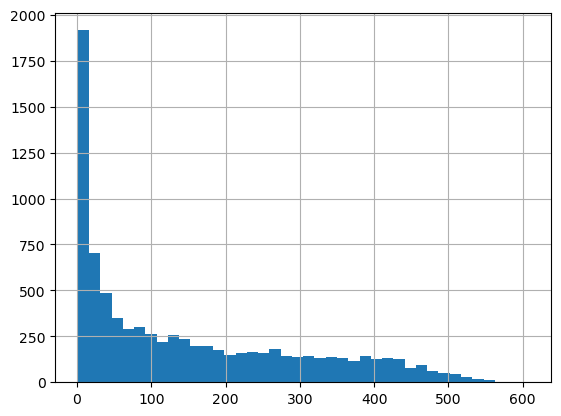

In [7]:
# remove observations where ev90<65
top90['bips'] = np.where(top90['ev90']<65, np.nan, top90['bips'])
top90['ev90'] = np.where(top90['ev90']<65, np.nan, top90['ev90'])

# plot a histogram of balls in play (BIPs)
top90['bips'].hist(bins=40)

In [8]:
# conditional on 90th percentile ev, compute avg pitch velo faced
top = evd.merge(top90, how='left', on=['batter','year'])
top = top.loc[top['launch_speed'] >= top['ev90']].reset_index(drop=True)
top = top.groupby(['batter','year']).agg(
        avg_pitch_velocity=('release_speed', 'mean'),
        bips_hard=('launch_speed', 'count')
).reset_index()

top90 = top90.merge(top, on=['batter','year'], how='left')
pop = pop.merge(top90, on=['batter','year'], how='left')

In [9]:
pop.head()

,batter,year,obs,swings_hand,ev90,ev50,ev_avg,bips,avg_pitch_velocity,bips_hard
0,112526,2016,232,103,100.06,80.0,82.870588,17.0,89.000000,2.0
1,112526,2017,64,37,87.00,77.7,78.033333,6.0,91.200000,1.0
2,112526,2018,15,7,76.90,76.9,76.900000,1.0,93.700000,1.0
3,120074,2016,2471,1078,107.40,94.8,93.186261,444.0,91.658696,46.0
4,121347,2016,915,449,106.31,93.2,89.761875,160.0,90.231250,16.0


In [10]:
# Now we compile Bat Speed data and merge onto the exit velocity dataframe
batspeed_data = data.loc[~data['bat_speed'].isna()].reset_index(drop=True)
bsd = batspeed_data.groupby([
    'batter','year'
    ]).agg(
        bat_speed =('bat_speed', 'mean'),
        bat_speed_sd =('bat_speed', 'std'),
        bat_speed_50 =('bat_speed', lambda x: np.percentile(x, 50)),
        swings=('bat_speed', 'count')
    ).reset_index()
pop = pop.merge(bsd, on=['batter','year'], how='left')

# merging the bio data onto the count data
df = pop.merge(player_bio, left_on=['batter'], right_on=['bam_id'], how='left')
df.tail()

,batter,year,obs,swings_hand,ev90,ev50,ev_avg,bips,avg_pitch_velocity,bips_hard,...,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
8831,814439,2026,757,335,102.66,91.20,88.151695,118.0,91.675000,12.0,...,814439,Ryan Waldschmidt,Ryan,Waldschmidt,R,CF,2002-10-07,Sarasota,FL,USA
8832,815873,2026,169,83,103.90,97.00,91.726087,23.0,94.225000,4.0,...,815873,Sean Keys,Sean,Keys,L,DH,2003-05-26,Huntington,NY,USA
8833,823550,2026,536,230,102.08,88.40,86.928235,85.0,92.866667,9.0,...,823550,Sung-Mun Song,Sung-Mun,Song,L,2B,1996-08-29,Seoul,NaN,Republic of Korea
8834,828599,2026,157,79,106.69,91.95,92.727273,22.0,91.200000,3.0,...,828599,Lucas Spence,Lucas,Spence,L,CF,2003-01-27,Chicago Heights,IL,USA
8835,829272,2025,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,829272,Shinnosuke Ogasawara,Shinnosuke,Ogasawara,L,P,1997-10-08,Fujisawa,NaN,Japan


In [11]:
# swings should always be more than bips
assert(len(df.loc[df['swings_hand']<df['bips']]) == 0)

In [12]:
# swings can be equal to bips, but rare
df.loc[(df['swings_hand']==df['bips'])&df['swings'].isnull()][['batter','year','obs','swings_hand','bips']]

,batter,year,obs,swings_hand,bips
143,429719,2018,3,2,2.0
194,433589,2019,4,1,1.0
398,448609,2017,2,1,1.0
422,450203,2017,11,3,3.0
514,453268,2021,2,1,1.0
...,...,...,...,...,...
7096,666137,2022,3,2,2.0
7479,669270,2019,2,1,1.0
7648,670298,2022,4,1,1.0
7683,670766,2021,10,2,2.0


In [13]:
# validate instances when we have observed swings
df.loc[(df['swings_hand']==df['bips'])&df['swings'].notnull()][['batter','year','obs','swings_hand','bips','swings']]

,batter,year,obs,swings_hand,bips,swings
6453,660636,2023,2,1,1.0,1.0
7418,669194,2025,4,1,1.0,1.0
7482,669288,2024,1,1,1.0,1.0
7772,672279,2026,4,1,1.0,1.0
7893,675915,2024,2,1,1.0,1.0
7995,676882,2023,1,1,1.0,1.0
8226,681190,2026,1,1,1.0,1.0


In [14]:
# validated swings are calcualted properly. Going to use swings from bat speed (observed swings with bat speed), otherwise swings_hand
df['swing_total'] = np.where(df['swings'].notnull(), df['swings'], df['swings_hand'])
df[['swings','swings_hand','swing_total']].head()

,swings,swings_hand,swing_total
0,NaN,103,103.0
1,NaN,37,37.0
2,NaN,7,7.0
3,NaN,1078,1078.0
4,NaN,449,449.0


In [15]:
# More transforming and cleaning....

# remove pitchers and encode a few different postitional groupings
df = df.loc[df['position']!='P'].reset_index(drop=True)
df['position'] = np.where(df['position']=='TWP','DH', df['position'])
df['position_group'] = np.where(df['position'].isin(['DH','1B','3B','LF','RF','OF']),'Power','Defense')
df['position_hybrid'] = np.where(df['position'].isin(['LF','RF','OF']),'COF',df['position'])
df['position_hybrid'] = np.where(df['position'].isin(['1B','3B']),'CINF',df['position_hybrid'])
df['position_hybrid'] = np.where(df['position'].isin(['SS','2B','CF']),'UTM',df['position_hybrid'])

# changing columns to floats
for c in ['ev90', 'bips','avg_pitch_velocity', 'bips_hard', 'bat_speed', 'bat_speed_sd','bat_speed_50','swings','age']:
    try:
        df[c] = df[c].astype(float)
    except KeyError:
        continue

# https://www.baseballprospectus.com/news/article/28956/baseball-therapy-the-one-about-exit-velocity/#:~:text=At%2040%2Dsomething%20balls%20in,to%20come%20in%20the%20season.
MIN_BIPS = 40
MIN_SWINGS = 10
# define approx thresholds based on prior studies
df['is_bip_threshold'] = np.where((df['bips']>=MIN_BIPS), 1, 0) # meets threshold
df['is_swing_threshold'] = np.where((df['swing_total']>=MIN_SWINGS), 1, 0) # meets threshold
df['is_ev90_na'] = np.where(df['ev90'].isna(), 1, 0) # have no ev90
df['is_bat_speed_na'] = np.where(df['bat_speed'].isna(), 1, 0) # have no bat speed
# remove the instances with no bips and no bat speed, we cant learn from players that never played
df = df.loc[~((df['is_bat_speed_na']==1) & (df['is_ev90_na']==1))].reset_index(drop=True)

In [16]:
# count unique players per bucket
posit = df[['batter','position','position_group','position_hybrid']].drop_duplicates(subset=['batter'])
p = posit.groupby(["position_group", "position_hybrid", "position"]).size().reset_index(name="count").sort_values(['position_group',"position_group", "position_hybrid", "position","count"], ascending=False)
q = df['position'].value_counts().reset_index()
p.merge(q, on=['position'])

,position_group,position_hybrid,position,count_x,count_y
0,Power,DH,DH,56,374
1,Power,COF,RF,179,705
2,Power,COF,OF,30,99
3,Power,COF,LF,218,824
4,Power,CINF,3B,183,776
5,Power,CINF,1B,179,760
6,Defense,UTM,SS,187,745
7,Defense,UTM,CF,197,731
8,Defense,UTM,2B,208,810
9,Defense,C,C,272,1149


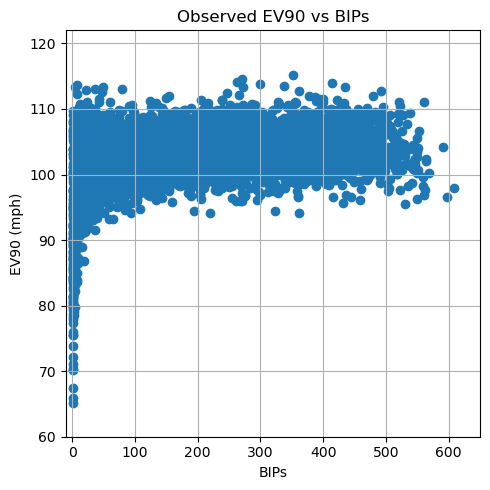

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.scatter(df['bips'], df['ev90'])
ax.set_xlabel('BIPs')
ax.set_ylabel('EV90 (mph)')
ax.set_title('Observed EV90 vs BIPs')
ax.set_xlim(-10, 650)
ax.set_ylim(60, 122)
ax.grid()
plt.tight_layout()

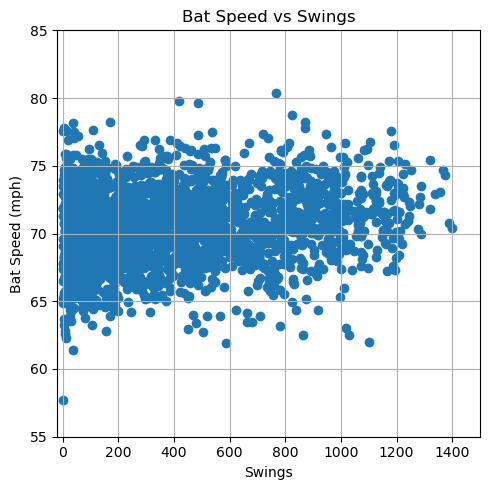

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.scatter(df['swing_total'], df['bat_speed'])
ax.set_xlabel('Swings')
ax.set_ylabel('Bat Speed (mph)')
ax.set_title('Bat Speed vs Swings')
ax.set_xlim(-20, 1500)
ax.set_ylim(55, 85)
ax.grid()
plt.tight_layout()

In [19]:
debut = df.dropna(subset=['ev90']).groupby('bam_id')['year'].min().reset_index().rename(columns={'year':'debut_year'})

seasons = sorted(pd.unique(df['year']))
year_month_index = pd.MultiIndex.from_product([seasons], names=['year']).to_frame(index=False).reset_index(drop=False).rename(columns={'index': 'time_index'})

grid_rows = []
for _, row in debut.iterrows():
    for season in [s for s in pd.unique(df['year']) if s >= row['debut_year']]:
        grid_rows.append({
            'bam_id': row['bam_id'],
            'year': season,
        })

grid = pd.DataFrame(grid_rows)
grid_shape = grid.shape[0]
grid = grid.merge(year_month_index, on=['year',], how='left')

subset_df = df[[
    'bam_id','year',
    'bips','ev90','ev50','ev_avg',
    'swing_total','bat_speed'
    ]]
grid = grid.merge(subset_df, on=['bam_id','year'], how='left')
assert grid.shape[0] == grid_shape

# bio data
bio_subset = df[[
    'bam_id','full','first','last','bats',
    'birth_date',
    'position','position_group','position_hybrid'
]].drop_duplicates(['bam_id'])
grid = grid.merge(bio_subset, on=['bam_id'], how='left')

assert grid.shape[0] == grid_shape
grid = grid.sort_values(['bam_id','year']).reset_index(drop=True)
grid.head(10)

,bam_id,year,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
0,120074,2016,0,444.0,107.4,94.8,93.186261,1078.0,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
1,120074,2017,1,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
2,120074,2018,2,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
3,120074,2019,3,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
4,120074,2020,4,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
5,120074,2021,5,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
6,120074,2022,6,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
7,120074,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
8,120074,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH
9,120074,2025,9,NaN,NaN,NaN,NaN,NaN,NaN,David Ortiz,David,Ortiz,L,1975-11-18,DH,Power,DH


In [20]:
# remove rows past last play by date
has_data = (~grid['bips'].isna()) | (~grid['swing_total'].isna())
last_idx = grid.loc[has_data].groupby('bam_id')['time_index'].max()
grid['last_idx'] = grid['bam_id'].map(last_idx)
remove = (grid['time_index'] > grid['last_idx']) & (grid['bips'].isna()) & (grid['swing_total'].isna())
grid=grid.loc[~remove].drop(columns='last_idx')
grid.loc[grid['bam_id']==405395].head()

,bam_id,year,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
121,405395,2016,0,511.0,106.50,93.20,91.584932,1153.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
122,405395,2017,1,502.0,103.69,90.45,88.706375,1172.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
123,405395,2018,2,403.0,104.36,91.60,90.028288,874.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
124,405395,2019,3,424.0,103.34,89.80,88.294340,928.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
125,405395,2020,4,125.0,101.66,90.20,88.603200,306.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF


In [21]:
grid.loc[grid['bam_id']==405395].tail()

,bam_id,year,time_index,bips,ev90,ev50,ev_avg,swing_total,bat_speed,full,first,last,bats,birth_date,position,position_group,position_hybrid
123,405395,2018,2,403.0,104.36,91.60,90.028288,874.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
124,405395,2019,3,424.0,103.34,89.80,88.294340,928.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
125,405395,2020,4,125.0,101.66,90.20,88.603200,306.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
126,405395,2021,5,232.0,105.57,91.95,90.298707,529.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF
127,405395,2022,6,258.0,106.10,93.80,91.214341,668.0,NaN,Albert Pujols,Albert,Pujols,R,1980-01-16,1B,Power,CINF


In [22]:
# now we compute age for every player in a month
# going to compute age measured on the 15th of each month
def get_age(row):
    bday = pd.to_datetime(row['birth_date'])
    ref_year = int(row['year'])
    ref_date = pd.Timestamp(year=ref_year, month=7, day=15)
    days_diff = (ref_date - bday).days
    age = days_diff/365.25
    return age

grid['age'] = grid.apply(get_age, axis=1)
grid = grid.reset_index(drop=True)

In [23]:
# peak at the younger players to confirm reasonable values
grid.loc[grid['age']<21][['birth_date','full','year','age']].sort_values(['age','year'])

,birth_date,full,year,age
5473,1998-10-25,Juan Soto,2018,19.720739
7003,2003-07-05,Junior Caminero,2023,20.027379
4528,1997-05-19,Victor Robles,2017,20.156057
6168,2000-05-16,Luis García Jr.,2020,20.164271
7208,2006-04-24,Konnor Griffin,2026,20.224504
5450,1999-03-16,Vladimir Guerrero Jr.,2019,20.331280
7053,2004-03-11,Jackson Chourio,2024,20.344969
6438,2001-03-01,Wander Franco,2021,20.372348
6993,2003-02-07,Jasson Domínguez,2023,20.432580
4518,1997-01-07,Ozzie Albies,2017,20.517454


In [24]:
round(grid['age'].describe(),1)

count    7257.0
mean       28.3
std         3.7
min        19.7
25%        25.7
50%        27.9
75%        30.7
max        44.7
Name: age, dtype: float64

In [25]:
grid.to_csv('agg_data_year.csv',index=False)

In [26]:
grid.shape

(7257, 18)

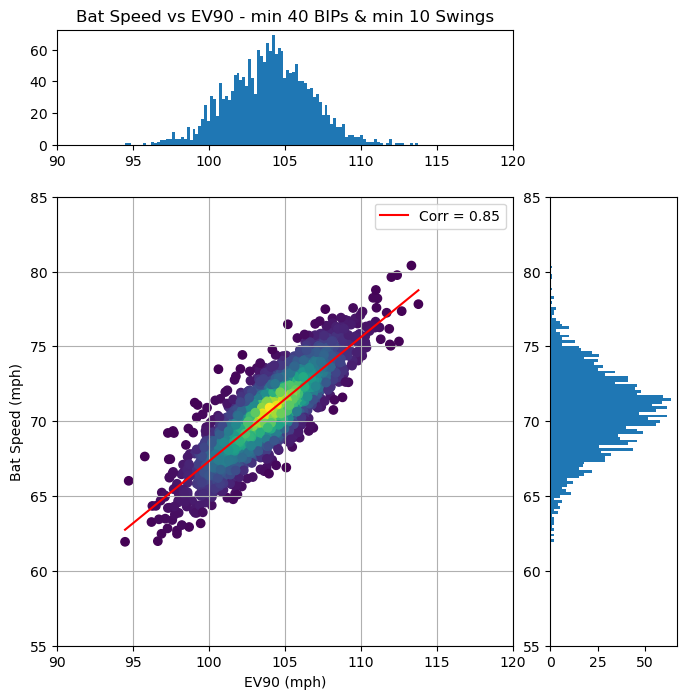

In [27]:
def draw_joint(fig, outer_cell, x, y, xlabel, ylabel, title, xlim=None, ylim=None, xticks=None, yticks=None, diag=False):
    gs = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=outer_cell, wspace=0.3, hspace=0.45)
    ax_joint = fig.add_subplot(gs[1:4, 0:3])
    ax_marg_x = fig.add_subplot(gs[0, 0:3])
    ax_marg_y = fig.add_subplot(gs[1:4, 3])

    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    ax_joint.scatter(x, y, c=density, cmap='viridis')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax_joint.plot(x_line, m * x_line + b, color='red', label=f'Corr = {np.corrcoef(x,y)[0,1]:.2f}')
    ax_joint.axline((0, 0), slope=1, color='black', linestyle='--')
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_xlim(xlim)
    ax_joint.set_ylim(ylim)
    ax_joint.set_xticks(xticks)
    ax_joint.set_yticks(yticks)
    ax_joint.set_ylabel(ylabel)
    ax_joint.legend()
    ax_joint.grid(True)
    ax_marg_x.hist(x, bins=100)
    ax_marg_y.hist(y, bins=100, orientation='horizontal')
    ax_marg_x.set_title(title)
    ax_marg_x.set_xticks(xticks)
    ax_marg_y.set_yticks(yticks)

fig = plt.figure(figsize=(8,8))
outer = gridspec.GridSpec(1, 1, figure=fig)

cd1 = grid.dropna(subset=['bat_speed', 'ev90']).copy()
cd1 = cd1.loc[(cd1['bips'] >= MIN_BIPS)&(cd1['swing_total'] >= MIN_SWINGS)]
x1, y1 = cd1['ev90'].values.astype(float), cd1['bat_speed'].values.astype(float)
draw_joint(fig, outer[0], x1, y1, 'EV90 (mph)', 'Bat Speed (mph)', f'Bat Speed vs EV90 - min {MIN_BIPS} BIPs & min {MIN_SWINGS} Swings',
           xlim = (90,120), ylim = (55,85), xticks = np.arange(90, 121, 5), yticks=np.arange(55, 86, 5)
        )

In [28]:
X = np.column_stack([np.ones(len(x1)), x1])
beta_hat = np.linalg.inv(X.T@X)@(X.T@y1)
intercept = beta_hat[0]
slope = beta_hat[1]
y_hat = X@beta_hat
resi = y1-y_hat
mse = np.mean((y1-y_hat)**2)
rss = np.sum((y1-y_hat)**2)
tss = np.sum((y1-np.mean(y1))**2)
r2 = 1-(rss/tss)
corr = np.corrcoef(x1, y1)[0, 1]

print(round(mse,2))
print(round(np.sqrt(mse),2))
print(round(r2,2))
print(round(corr,2))
print(round(corr**2,2))

1.94
1.39
0.73
0.85
0.73
